In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy
import torch

from matplotlib import pyplot
from tqdm.auto import tqdm, trange

from tiffwrapper import make_composite

In [3]:
from stedfm import get_pretrained_model_v2
from stedfm.models.classifier import MetaLinearProbe

from stedfm.datasets.multichannel import get_dataset

model, cfg = get_pretrained_model_v2(
    name="mae-mcms-token-lightning-small",
    weights="MAE_MCMS_TOKEN_SMALL_STED",
    as_classifier=True,
    classifier_type=MetaLinearProbe
)
# model, cfg = get_pretrained_model_v2(
#     name="mae-lightning-small",
#     weights="MAE_SMALL_STED",
#     as_classifier=True,
#     classifier_type=MetaLinearProbe
# )


classifier_type <class 'stedfm.models.classifier.MetaLinearProbe'>
in_channels 1
--- mae-lightning-small | (https://s3.valeria.science/flclab-foundation-models/models/mae-small-sted.zip) Downloading from URL and extracting zip ---

Loading state_dict from /home-local2/projects/SSL/baselines/mae-small_STED/pl_checkpoint-999.pth
--- mae-mcms-token-lightning-small | (/home-local2/projects/SSL/baselines/mae-mcms-token-small_STED/current_model.pth) Loading from local file ---

--- Loaded model mae-mcms-token-lightning-small with weights MAE_MCMS_TOKEN_SMALL_STED ---
--- Adding linear probe on top of mae-mcms-token-lightning-small ---
--- Added linear probe to all frozen blocks ---


# Default images

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
model.to(device)

CLASSES = ["Homer-Bassoon-Block", "Homer-PSD95-Block"]
# CLASSES = None
dataset = get_dataset("pysoda", cfg, cache=False, classes=CLASSES)
print(f"Dataset length: {len(dataset)}")

all_features, all_labels = [], []
for i in trange(len(dataset)):
    image, metadata = dataset[i]
    image = image.to(device)

    pixel_size = metadata.get("pixel_size", 0.015)
    features = model.forward_features(image.unsqueeze(0), pixel_size=pixel_size)
    all_features.append(features.squeeze(0).cpu().numpy())
    all_labels.append(metadata["label"])

Dataset length: 26


  0%|          | 0/26 [00:00<?, ?it/s]

Explained variance ratio: [0.48818848 0.16464749 0.11554848 0.07058029 0.03654712 0.03083487
 0.02091875 0.01525418 0.01456974 0.00862562]
cumulative explained variance ratio: [0.48818848 0.65283597 0.76838446 0.83896476 0.8755119  0.90634674
 0.92726547 0.94251966 0.9570894  0.96571505]


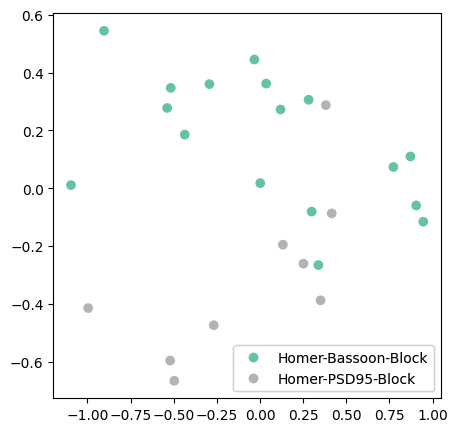

In [22]:
# Plot PCA
from sklearn.decomposition import PCA

X_features = numpy.array(all_features)

pca = PCA(n_components=10)
features_2d = pca.fit_transform(X_features)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print("cumulative explained variance ratio:", numpy.cumsum(pca.explained_variance_ratio_))

x_feature_idx = 0
y_feature_idx = 1
fig, ax = pyplot.subplots(figsize=(5, 5))
scatter = ax.scatter(features_2d[:,x_feature_idx], features_2d[:,y_feature_idx], c=all_labels, cmap="Set2")
legend1 = ax.legend(
    handles=scatter.legend_elements()[0], 
    labels=[dataset.classes[l] for l in set(all_labels)])
ax.add_artist(legend1)
pyplot.show()

/opt/anaconda3/envs/ssl/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/ssl/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


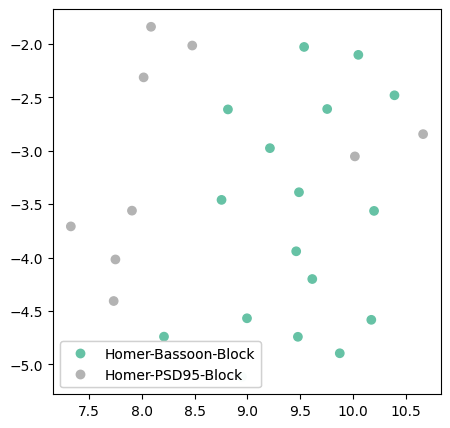

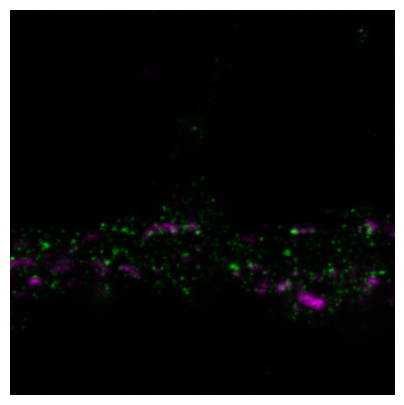

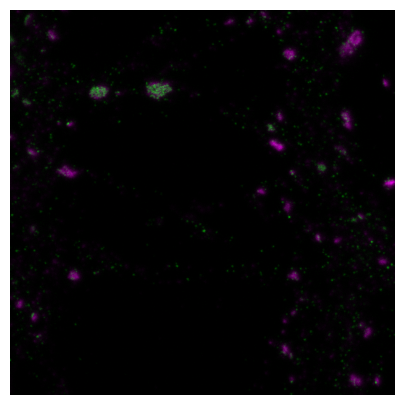

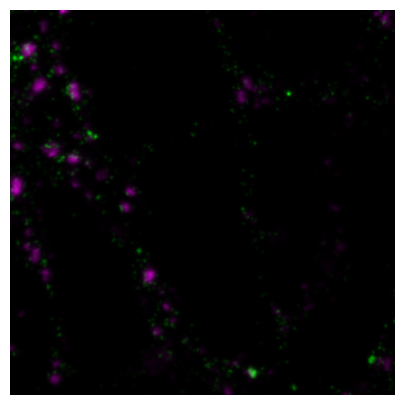

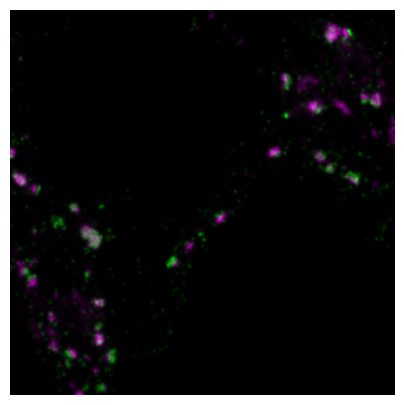

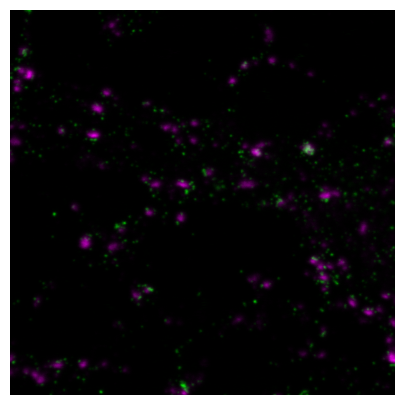

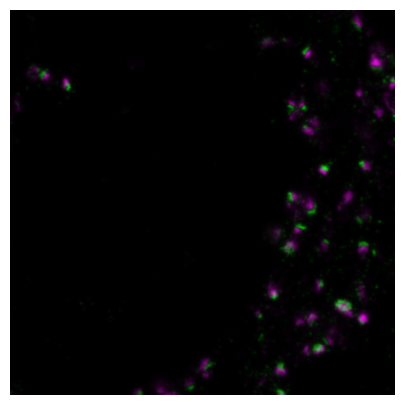

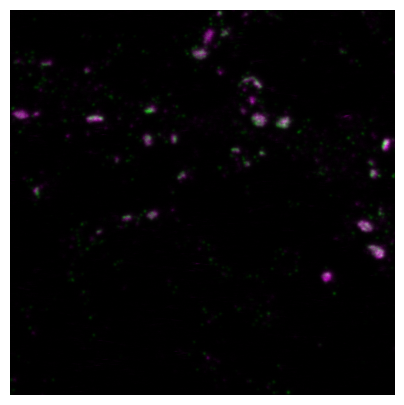

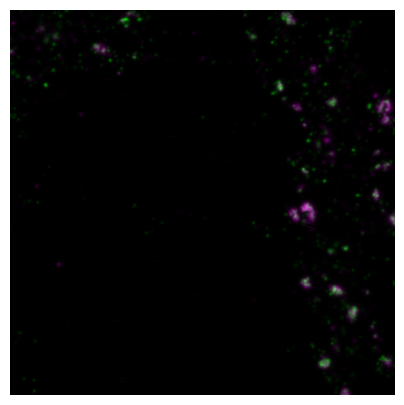

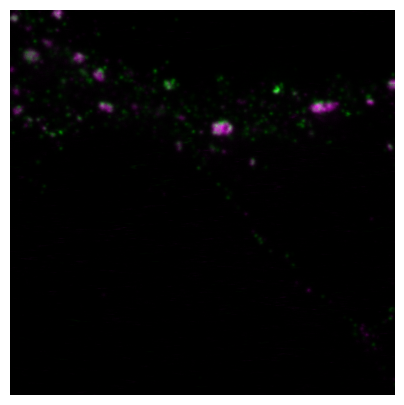

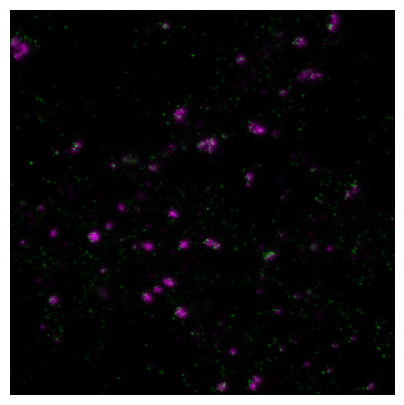

Done.


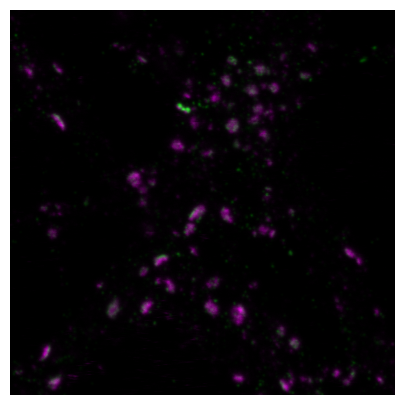

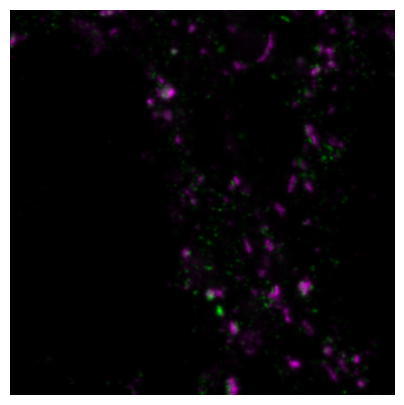

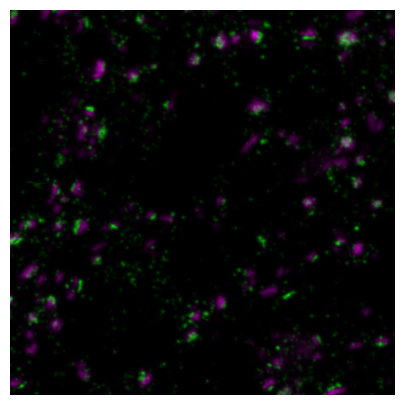

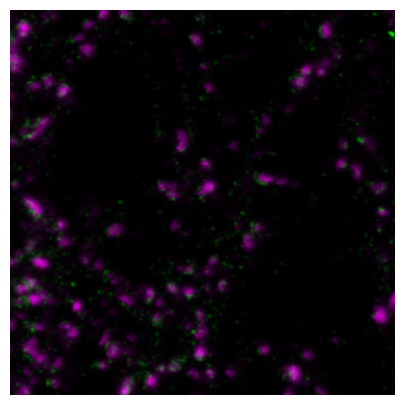

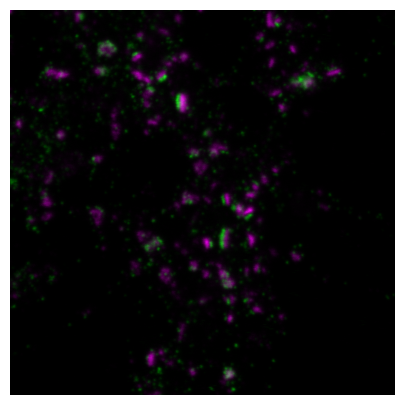

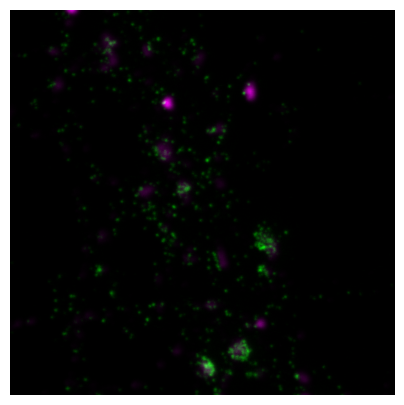

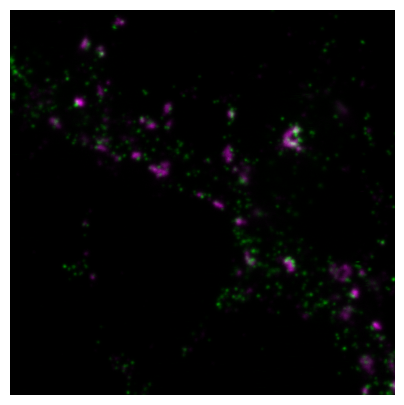

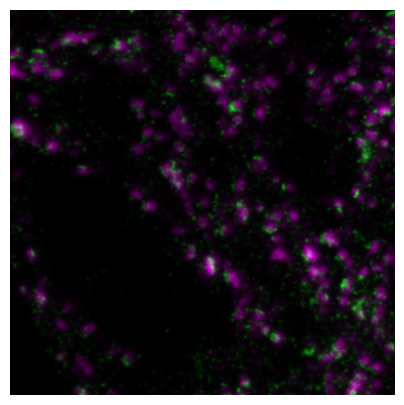

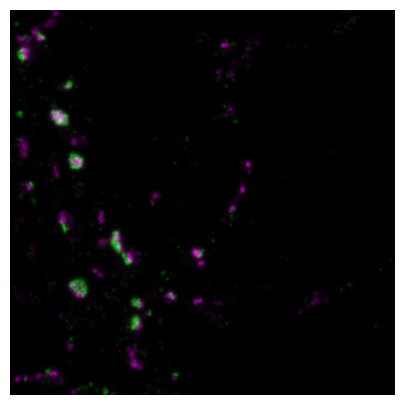

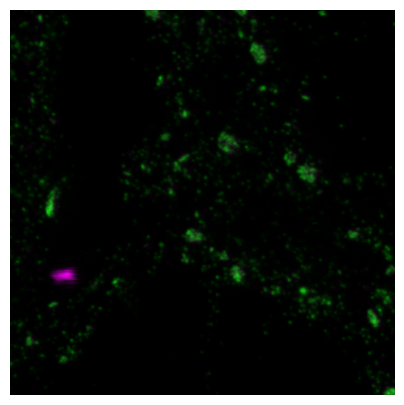

In [23]:
# Plot umap
import umap
reducer = umap.UMAP(random_state=42)

X_features = numpy.array(all_features)
X_features = (X_features - X_features.mean(axis=0)) / (X_features.std(axis=0) + 1e-8)  # Center and scale the data

# 10 features keeps about 95% of the variance
pca_transformed_features = PCA(n_components=16).fit_transform(X_features)
# features_umap = reducer.fit_transform(pca_transformed_features[:, 1:])
features_umap = reducer.fit_transform(X_features)

fig, ax = pyplot.subplots(figsize=(5, 5))
scatter = ax.scatter(features_umap[:,0], features_umap[:,1], c=all_labels, cmap="Set2")
legend1 = ax.legend(
    handles=scatter.legend_elements()[0], 
    labels=[dataset.classes[l] for l in set(all_labels)])
ax.add_artist(legend1)
pyplot.show()

threshold = features_umap[:, 0].mean()

mask = features_umap[:, 0] < threshold
choice = numpy.random.choice(numpy.where(mask)[0], size=10, replace=False)
for idx in choice:
    fig, ax = pyplot.subplots(figsize=(5, 5), frameon=False)
    to_display = make_composite(dataset[idx][0].numpy(), luts=["green", "magenta"])
    ax.imshow(to_display, cmap="gray")
    # ax.xaxis.set_visible(False)
    # ax.yaxis.set_visible(False)
    ax.axis("off")
    pyplot.show()

print("Done.")

mask = features_umap[:, 0] > threshold
choice = numpy.random.choice(numpy.where(mask)[0], size=10, replace=False)
for idx in choice:
    fig, ax = pyplot.subplots(figsize=(5, 5), frameon=False)
    to_display = make_composite(dataset[idx][0].numpy(), luts=["green", "magenta"])
    ax.imshow(to_display, cmap="gray")
    # ax.xaxis.set_visible(False)
    # ax.yaxis.set_visible(False)
    ax.axis("off")
    pyplot.show()

# Non-coherent channels

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
model.to(device)

dataset = get_dataset("pysoda", cfg, cache=False, classes=CLASSES)
print(f"Dataset length: {len(dataset)}")

all_non_coherent_features, all_non_coherent_labels = [], []
for repeat in range(1):
    for i in trange(len(dataset)):
        image, metadata = dataset[i]
        image = image.to(device)

        # Sample another image and change the one channel
        other_idx = numpy.random.choice(len(dataset))
        other_image, _ = dataset[other_idx]
        other_image = other_image.to(device)

        image[1] = other_image[1]

        pixel_size = metadata.get("pixel_size", 0.015)
        features = model.forward_features(image.unsqueeze(0), pixel_size=pixel_size)
        all_non_coherent_features.append(features.squeeze(0).cpu().numpy())
        all_non_coherent_labels.append(metadata["label"])

Detected classes:  ['Homer-PSD95-Block', 'Homer-Bassoon-Block', 'Bassoon-PSD95-Block', 'Rim-Bassoon-Block']
Dataset length: 60


  0%|          | 0/60 [00:00<?, ?it/s]

Explained variance ratio: [0.59843063 0.11885171 0.07047682 0.05426419 0.02873052 0.02714883
 0.01756579 0.01109202 0.00990483 0.00731436]
cumulative explained variance ratio: [0.59843063 0.71728235 0.7877592  0.8420234  0.8707539  0.8979027
 0.9154685  0.9265605  0.9364654  0.94377977]


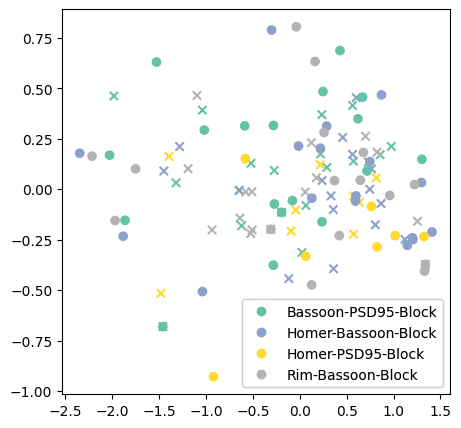

/opt/anaconda3/envs/ssl/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/ssl/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


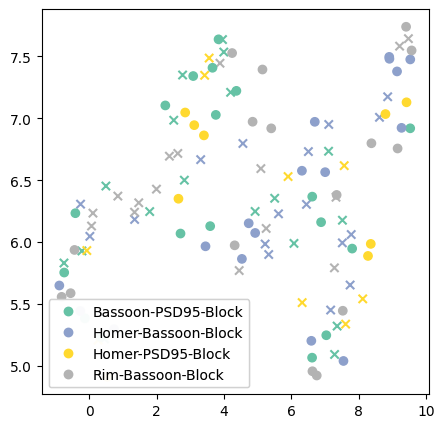

In [9]:
# Plot PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=10)

combined_features = numpy.concatenate([all_features, all_non_coherent_features], axis=0)
combined_labels = numpy.concatenate([all_labels, all_non_coherent_labels], axis=0)

features_2d = pca.fit_transform(combined_features)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print("cumulative explained variance ratio:", numpy.cumsum(pca.explained_variance_ratio_))

x_feature_idx = 0
y_feature_idx = 2
fig, ax = pyplot.subplots(figsize=(5, 5))
mask = numpy.array([0] * len(all_features) + [1] * len(all_non_coherent_features), dtype=bool)
scatter = ax.scatter(
    features_2d[mask,x_feature_idx], features_2d[mask,y_feature_idx], c=combined_labels[mask], cmap="Set2",
    marker="x")
scatter = ax.scatter(
    features_2d[~mask,x_feature_idx], features_2d[~mask,y_feature_idx], c=combined_labels[~mask], cmap="Set2")
legend1 = ax.legend(
    handles=scatter.legend_elements()[0], 
    labels=[dataset.classes[l] for l in set(combined_labels)])
ax.add_artist(legend1)
pyplot.show()

mapper = umap.UMAP(random_state=42)
X_transformed = mapper.fit_transform(combined_features)
fig, ax = pyplot.subplots(figsize=(5, 5))
scatter = ax.scatter(
    X_transformed[mask,0], X_transformed[mask,1], c=combined_labels[mask], cmap="Set2",
    marker="x")
scatter = ax.scatter(
    X_transformed[~mask,0], X_transformed[~mask,1], c=combined_labels[~mask], cmap="Set2")
legend1 = ax.legend(
    handles=scatter.legend_elements()[0], 
    labels=[dataset.classes[l] for l in set(combined_labels)])
ax.add_artist(legend1)
pyplot.show()

# Find discriminative features in coherent channels

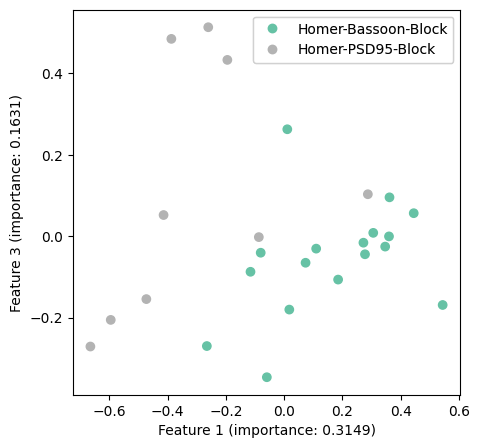

In [24]:

from sklearn.decomposition import PCA

pca = PCA(n_components=min(10, len(all_features)))
X_transformed = pca.fit_transform(all_features)

# feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_transformed, all_labels, test_size=0.2, random_state=42, shuffle=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf.fit(X_transformed, all_labels)

importances = rf.feature_importances_
sorted_indices = numpy.argsort(importances)[::-1]

fig, ax = pyplot.subplots(figsize=(5, 5))
ax.scatter(X_transformed[:, sorted_indices[0]], X_transformed[:, sorted_indices[1]], c=all_labels, cmap="Set2")
ax.set_xlabel(f"Feature {sorted_indices[0]} (importance: {importances[sorted_indices[0]]:.4f})")
ax.set_ylabel(f"Feature {sorted_indices[1]} (importance: {importances[sorted_indices[1]]:.4f})")
legend1 = ax.legend(
    handles=ax.collections[0].legend_elements()[0], 
    labels=[dataset.classes[l] for l in set(all_labels)])
ax.add_artist(legend1)
pyplot.show()


## Attribution of PCA components

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# device = "cpu"
model.to(device)

all_patch_features, all_labels = [], []
for i in trange(len(dataset)):
    image, metadata = dataset[i]
    image = image.to(device)

    pixel_size = metadata.get("pixel_size", 0.015)
    _, patch_features = model.forward_features(image.unsqueeze(0), pixel_size=pixel_size, return_patches=True)
    all_patch_features.append(patch_features.squeeze(0).cpu().numpy())
    all_labels.append(metadata["label"])